In [1]:
# ============================================================
# S4: KD STUDENT + ARTIFACT-WEIGHTED LOSS (no gate)
#
# S3's artifact-GATED fusion underperformed S2's simple concat
# fusion (F1: 0.5185 < 0.5219). Instead of shifting trust toward
# E4 on noisy epochs (gating), this script keeps the simpler S2
# architecture (concat fusion) and instead scales each epoch's
# contribution to the LOSS by its Zmax artifact quality:
#
#   clean epoch  (artifact_weight = 1.0) -> full loss contribution
#   noisy epoch  (artifact_weight < 1.0) -> reduced loss contribution
#   no-data epoch(artifact_weight = 0.0) -> excluded from CE entirely
#
# i.e. the model still SEES both Zmax and E4 for every epoch
# (no gating/re-routing), but it is trained to rely less on what
# it learns from noisy epochs overall, and more on clean ones --
# exactly the "learn less from noisy, more from clean" behavior
# you asked for, applied at the loss level rather than the
# fusion level.
#
#   L = L_artifact-weighted-CE + lambda_KD * L_KD
#
# Compare against S2 (F1=0.5219, no artifact info at all) and
# S3 (F1=0.5185, gated fusion) to see which mechanism for using
# artifact information actually helps.
# ============================================================

import os
import csv
import math
import random
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
warnings.filterwarnings('ignore')

# ============================================================
# PATHS
# ============================================================
PSG_EEG_PATH      = r"D:\22\AA\preprocess\preprocessed_FFinal"
STUDENT_DATA_PATH = r"D:\22\AA\preprocess\preprocessed_student_zmax_e4"
TEACHER_CKPT_DIR  = r"D:\22\AA\evaluation\multiscale_plain_c7_88%"
EVAL_PATH         = r"D:\22\AA\evaluation\teacher-student\s3_artifact_weighted_kd"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 7
WINDOW      = 2 * CONTEXT + 1
N_EPOCHS    = 30
BATCH_SIZE  = 64
SEEDS         = [42, 123, 256, 789, 999]
TEACHER_SEEDS = [42, 123, 256, 789, 999]

T_D_MODEL = 128
T_DROPOUT = 0.4
T_N_HEADS = 4

S_D_MODEL = 96
S_DROPOUT = 0.3

KD_LAMBDA      = 1.0
KD_TEMPERATURE = 3.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"S4: Concat fusion (same as S2) + KD + ARTIFACT-WEIGHTED CE loss")
print(f"KD lambda     : {KD_LAMBDA}   Temperature: {KD_TEMPERATURE}")
print(f"Teacher       : MultiScaleSleepNetPlain, 5-seed ensemble (frozen)")
print(f"Output        : {EVAL_PATH}")


# ============================================================
# ============  TEACHER ARCHITECTURE (frozen)  ================
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.shape
        s = self.pool(x).view(b, c)
        s = self.fc(s).view(b, c, 1)
        return x * s


class MultiScaleCNN(nn.Module):
    def __init__(self, in_ch=3, d_model=T_D_MODEL, dropout=T_DROPOUT):
        super().__init__()
        mid = d_model // 4

        def time_branch(kernel):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=kernel, stride=6, padding=kernel // 2),
                nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(4, 4),
                nn.Conv1d(mid, mid, kernel_size=8, padding=4),
                nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(2, 2),
                nn.Dropout(dropout),
            )

        self.small  = time_branch(25)
        self.medium = time_branch(50)
        self.large  = time_branch(100)

        self.spectral = nn.Sequential(
            nn.Conv1d(in_ch, mid, kernel_size=25, stride=6, padding=12),
            nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(4, 4),
            nn.Conv1d(mid, mid, kernel_size=8, padding=4),
            nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, 3000)
            L_s = self.small(dummy).shape[2]
            L_m = self.medium(dummy).shape[2]
            L_l = self.large(dummy).shape[2]
            L_f = self.spectral(dummy).shape[2]

        target_L = min(L_s, L_m, L_l, L_f)
        self.pool_s = nn.AdaptiveAvgPool1d(target_L)
        self.pool_m = nn.AdaptiveAvgPool1d(target_L)
        self.pool_l = nn.AdaptiveAvgPool1d(target_L)
        self.pool_f = nn.AdaptiveAvgPool1d(target_L)
        self.out_len = target_L

        self.se = SEBlock(4 * mid)
        self.proj = nn.Sequential(
            nn.Conv1d(4 * mid, d_model, kernel_size=1),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )

    def forward(self, x):
        fs = self.pool_s(self.small(x))
        fm = self.pool_m(self.medium(x))
        fl = self.pool_l(self.large(x))

        x_fft = torch.fft.rfft(x, dim=-1)
        x_mag = torch.abs(x_fft)
        if x_mag.shape[-1] < x.shape[-1]:
            pad = x.shape[-1] - x_mag.shape[-1]
            x_mag = F.pad(x_mag, (0, pad))
        else:
            x_mag = x_mag[..., :x.shape[-1]]
        ff = self.pool_f(self.spectral(x_mag))

        feat = torch.cat([fs, fm, fl, ff], dim=1)
        feat = self.se(feat)
        return self.proj(feat)


class BiLSTMTransformerBlock(nn.Module):
    def __init__(self, d_model=T_D_MODEL, n_heads=T_N_HEADS, dropout=T_DROPOUT):
        super().__init__()
        self.bilstm = nn.LSTM(
            d_model, d_model // 2, num_layers=1,
            batch_first=True, bidirectional=True
        )
        self.norm1 = nn.LayerNorm(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 2, dropout=dropout,
            batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        lstm_out, _ = self.bilstm(x)
        x = self.norm1(x + lstm_out)
        attn_out = self.transformer(x)
        return self.norm2(x + attn_out)


class MultiScaleSleepNetPlain(nn.Module):
    """Teacher architecture -- identical to your trained checkpoints."""
    def __init__(self, in_ch=3, d_model=T_D_MODEL, n_layers=2,
                 dropout=T_DROPOUT, n_classes=5, context=CONTEXT):
        super().__init__()
        self.context = context
        self.d_model = d_model
        self.cnn = MultiScaleCNN(in_ch=in_ch, d_model=d_model, dropout=dropout)
        self.intra_blocks = nn.Sequential(*[
            BiLSTMTransformerBlock(d_model, dropout=dropout) for _ in range(n_layers)
        ])
        self.inter_pos = nn.Parameter(torch.randn(1, WINDOW, d_model) * 0.01)
        self.inter_blocks = nn.Sequential(*[
            BiLSTMTransformerBlock(d_model, dropout=dropout) for _ in range(n_layers)
        ])
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, n_classes),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        cnn_out = self.cnn(x.view(B * W, C, T)).permute(0, 2, 1)
        intra = self.intra_blocks(cnn_out)
        epoch_feat = intra.mean(dim=1).view(B, W, self.d_model)
        inter = self.inter_blocks(epoch_feat + self.inter_pos)
        center = inter[:, self.context, :]
        return self.classifier(center)


# ============================================================
# ========  STUDENT ARCHITECTURE (S2's concat fusion)  =========
# No gate -- both modalities always contribute equally to the
# representation. Artifact info is used ONLY in the loss below.
# ============================================================
class ZmaxEEGEncoder(nn.Module):
    def __init__(self, in_ch=2, d_model=S_D_MODEL, dropout=S_DROPOUT):
        super().__init__()
        mid = d_model // 2

        def branch(kernel):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=kernel, stride=4, padding=kernel // 2),
                nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(2, 2), nn.Dropout(dropout)
            )
        self.small, self.large = branch(15), branch(60)
        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, 1920)
            L_s, L_l = self.small(dummy).shape[2], self.large(dummy).shape[2]
        target_L = min(L_s, L_l)
        self.pool_s = nn.AdaptiveAvgPool1d(target_L)
        self.pool_l = nn.AdaptiveAvgPool1d(target_L)
        self.proj = nn.Sequential(nn.Conv1d(2 * mid, d_model, kernel_size=1),
                                   nn.BatchNorm1d(d_model), nn.GELU())
        self.gru = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        fs, fl = self.pool_s(self.small(x)), self.pool_l(self.large(x))
        feat = self.proj(torch.cat([fs, fl], dim=1)).permute(0, 2, 1)
        gru_out, _ = self.gru(feat)
        return self.norm(feat.mean(dim=1) + gru_out.mean(dim=1))


class E4Encoder(nn.Module):
    def __init__(self, in_ch=3, d_model=S_D_MODEL, dropout=S_DROPOUT):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, d_model // 2, kernel_size=15, stride=4, padding=7),
            nn.BatchNorm1d(d_model // 2), nn.GELU(), nn.MaxPool1d(2, 2),
            nn.Conv1d(d_model // 2, d_model, kernel_size=8, padding=4),
            nn.BatchNorm1d(d_model), nn.GELU(), nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )
        self.gru = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        feat = self.conv(x).permute(0, 2, 1)
        gru_out, _ = self.gru(feat)
        return self.norm(feat.mean(dim=1) + gru_out.mean(dim=1))


class WearableStudentModel(nn.Module):
    """Identical to S2 -- simple concat fusion, no gate."""
    def __init__(self, d_model=S_D_MODEL, n_classes=5, dropout=S_DROPOUT):
        super().__init__()
        self.zmax_enc = ZmaxEEGEncoder(in_ch=2, d_model=d_model, dropout=dropout)
        self.e4_enc   = E4Encoder(in_ch=3, d_model=d_model, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model * 2), nn.Linear(d_model * 2, 64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, n_classes)
        )

    def forward(self, zmax_x, e4_x):
        z = self.zmax_enc(zmax_x)
        e = self.e4_enc(e4_x)
        fused = torch.cat([z, e], dim=1)
        logits = self.classifier(fused)
        return logits


# ============================================================
# COMBINED DATASET (returns artifact_weight, used only in loss)
# ============================================================
class KDDataset(Dataset):
    def __init__(self, subject_list, psg_path, student_path, context=CONTEXT):
        self.context = context
        self.data = []
        self.index = []

        skipped_mismatch = 0
        for sub in subject_list:
            psg_fp = os.path.join(psg_path, f"{sub}.npz")
            stu_fp = os.path.join(student_path, f"{sub}.npz")
            if not (os.path.exists(psg_fp) and os.path.exists(stu_fp)):
                continue

            with np.load(psg_fp) as d:
                eeg = d['eeg'][:, [0, 1], :]
                eog = d['eog'][:, [0], :]
                psg_signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                psg_labels = d['labels'].copy()

            with np.load(stu_fp) as d:
                zmax_arr = d['zmax_eeg']
                e4_arr   = d['e4']
                stu_labels = d['labels'].copy()
                art_w = d['artifact_weight']

            n = min(len(psg_labels), len(stu_labels))
            if abs(len(psg_labels) - len(stu_labels)) > 5:
                skipped_mismatch += 1

            sub_idx = len(self.data)
            self.data.append((psg_signal, psg_labels, zmax_arr, e4_arr, art_w, stu_labels))
            for i in range(n):
                self.index.append((sub_idx, i, n))

        print(f"  Subjects loaded: {len(self.data)}  (large mismatches: {skipped_mismatch})")
        print(f"  Samples: {len(self.index):,}")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n = self.index[idx]
        psg_signal, psg_labels, zmax_arr, e4_arr, art_w, stu_labels = self.data[sub_idx]

        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(psg_signal[ei])
        psg_x = np.stack(window_epochs, axis=0)

        ei = min(center_i, zmax_arr.shape[0] - 1, e4_arr.shape[0] - 1)
        zmax_x = zmax_arr[ei]
        e4_x   = e4_arr[ei]
        aw     = float(art_w[ei]) if ei < len(art_w) else 1.0

        y = int(stu_labels[center_i]) if center_i < len(stu_labels) else int(psg_labels[center_i])

        return (
            torch.FloatTensor(psg_x),
            torch.FloatTensor(zmax_x),
            torch.FloatTensor(e4_x),
            torch.tensor(aw, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long),
        )


# ============================================================
# LOAD SPLIT + BUILD DATASETS
# ============================================================
_train_path = os.path.join(PSG_EEG_PATH, "_train_subs.npy")
_test_path  = os.path.join(PSG_EEG_PATH, "_test_subs.npy")
TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
print(f"Split loaded -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")

print("\nBuilding KD datasets...")
train_ds = KDDataset(TRAIN_SUBS, PSG_EEG_PATH, STUDENT_DATA_PATH)
print()
test_ds  = KDDataset(TEST_SUBS, PSG_EEG_PATH, STUDENT_DATA_PATH)
print("Datasets ready.")


# ============================================================
# LOAD FROZEN TEACHER ENSEMBLE
# ============================================================
print(f"\nLoading {len(TEACHER_SEEDS)} frozen teacher checkpoints...")
teachers = []
for seed in TEACHER_SEEDS:
    ckpt = os.path.join(TEACHER_CKPT_DIR, f"best_seed{seed}.pt")
    if not os.path.exists(ckpt):
        print(f"  MISSING: {ckpt}")
        continue
    m = MultiScaleSleepNetPlain(in_ch=3).to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()
    for p in m.parameters():
        p.requires_grad = False
    teachers.append(m)
print(f"Loaded {len(teachers)} teacher models (frozen).")


@torch.no_grad()
def teacher_soft_targets(psg_x, temperature=KD_TEMPERATURE):
    probs_sum = None
    for m in teachers:
        logits = m(psg_x)
        probs = F.softmax(logits / temperature, dim=1)
        probs_sum = probs if probs_sum is None else probs_sum + probs
    return probs_sum / len(teachers)


# ============================================================
# CLASS WEIGHTS
# ============================================================
all_train_labels = []
for _, _, _, _, _, labs in train_ds.data:
    all_train_labels.extend(labs.tolist())
label_counts = np.array([Counter(all_train_labels).get(i, 1) for i in range(5)], dtype=np.float32)
cw = torch.FloatTensor(label_counts.sum() / (5 * label_counts)).to(device)
print(f"\nClass weights: {dict(zip(LABEL_NAMES, cw.cpu().numpy().round(3)))}")


def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def artifact_weighted_kd_loss_fn(student_logits, teacher_probs, labels, artifact_weight,
                                  temperature, lam, class_weights):
    """
    L = artifact_weighted_CE + lambda_KD * L_KD

    The CE term is scaled per-sample by artifact_weight, so noisy
    epochs (low weight) contribute less to the gradient and clean
    epochs (weight=1.0) contribute fully. The KD term is left
    unweighted -- the teacher's soft label is still valid signal
    regardless of the STUDENT's input quality, since the teacher
    itself saw clean PSG for that epoch.
    """
    student_log_probs = F.log_softmax(student_logits / temperature, dim=1)
    kd = F.kl_div(student_log_probs, teacher_probs, reduction='batchmean') * (temperature ** 2)

    ce_per_sample = F.cross_entropy(student_logits, labels, weight=class_weights, reduction='none')
    weighted_ce = ce_per_sample * artifact_weight
    valid = artifact_weight > 0
    ce = weighted_ce[valid].mean() if valid.sum() > 0 else weighted_ce.mean()

    total = ce + lam * kd
    return total, kd.item(), ce.item()


def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = total_kd = total_ce = 0
    preds, labs_all = [], []
    for psg_x, zmax_x, e4_x, aw, y in loader:
        psg_x, zmax_x, e4_x, aw, y = (
            psg_x.to(device), zmax_x.to(device), e4_x.to(device),
            aw.to(device), y.to(device)
        )
        optimizer.zero_grad()
        teacher_probs = teacher_soft_targets(psg_x)
        student_logits = model(zmax_x, e4_x)
        loss, kd_val, ce_val = artifact_weighted_kd_loss_fn(
            student_logits, teacher_probs, y, aw, KD_TEMPERATURE, KD_LAMBDA, cw
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item(); total_kd += kd_val; total_ce += ce_val
        preds.extend(student_logits.argmax(1).cpu().numpy())
        labs_all.extend(y.cpu().numpy())

    n = len(loader)
    acc = accuracy_score(labs_all, preds)
    f1 = f1_score(labs_all, preds, average='macro', zero_division=0)
    return total_loss / n, total_kd / n, total_ce / n, acc, f1


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, labs_all, aw_all = [], [], []
    for psg_x, zmax_x, e4_x, aw, y in loader:
        zmax_x, e4_x = zmax_x.to(device), e4_x.to(device)
        logits = model(zmax_x, e4_x)
        preds.extend(logits.argmax(1).cpu().numpy())
        labs_all.extend(y.numpy())
        aw_all.extend(aw.numpy())
    preds, labs_all, aw_all = np.array(preds), np.array(labs_all), np.array(aw_all)

    acc = accuracy_score(labs_all, preds)
    f1 = f1_score(labs_all, preds, average='macro', zero_division=0)
    kappa = cohen_kappa_score(labs_all, preds)
    per_cls = f1_score(labs_all, preds, average=None, zero_division=0)

    clean_mask = aw_all >= 0.9
    noisy_mask = (aw_all > 0) & (aw_all < 0.5)
    clean_acc = accuracy_score(labs_all[clean_mask], preds[clean_mask]) if clean_mask.sum() > 0 else float('nan')
    noisy_acc = accuracy_score(labs_all[noisy_mask], preds[noisy_mask]) if noisy_mask.sum() > 0 else float('nan')

    return acc, f1, kappa, per_cls, clean_acc, noisy_acc


# ============================================================
# TRAINING LOOP
# ============================================================
csv_path = os.path.join(EVAL_PATH, "summary.csv")
fields = ["seed", "acc", "f1_macro", "kappa", "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM",
          "clean_acc", "noisy_acc"]
with open(csv_path, 'w', newline='') as f:
    csv.DictWriter(f, fields).writeheader()

all_results = []
for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}\nSTUDENT SEED {seed}  ({seed_idx+1}/{len(SEEDS)})\n{'='*60}")
    set_seed(seed)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=0, generator=torch.Generator().manual_seed(seed))
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = WearableStudentModel().to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Student parameters: {n_params:,}  (teacher frozen, not counted)")

    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=3e-4, betas=(0.9, 0.98), eps=1e-9)
    total_steps = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine)

    best_f1 = 0.0
    best_path = os.path.join(EVAL_PATH, f"best_student_seed{seed}.pt")

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_kd, tr_ce, tr_acc, tr_f1 = train_epoch(model, train_loader, optimizer, scheduler)
        vl_acc, vl_f1, vl_kap, vl_per, clean_acc, noisy_acc = evaluate(model, test_loader)

        saved = ""
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        print(f"  Ep[{epoch:02d}/{N_EPOCHS}] Loss:{tr_loss:.3f}(CE:{tr_ce:.3f}+KD:{tr_kd:.3f}) "
              f"TrF1:{tr_f1:.3f} ValAcc:{vl_acc:.3f} F1:{vl_f1:.3f} k:{vl_kap:.3f} "
              f"clean:{clean_acc:.3f} noisy:{noisy_acc:.3f}{saved}")

    model.load_state_dict(torch.load(best_path, map_location=device))
    fin_acc, fin_f1, fin_kap, fin_per, fin_clean, fin_noisy = evaluate(model, test_loader)

    print(f"\n  Seed {seed} FINAL: Acc={fin_acc*100:.2f}% F1={fin_f1:.4f} k={fin_kap:.4f}")
    print(f"  Clean-epoch acc: {fin_clean:.3f}   Noisy-epoch acc: {fin_noisy:.3f}")
    for i, name in enumerate(LABEL_NAMES):
        print(f"    {name:6s}: {fin_per[i]:.4f}")

    all_results.append({
        'seed': seed, 'acc': fin_acc, 'f1': fin_f1, 'kappa': fin_kap, 'per_cls': fin_per,
        'clean_acc': fin_clean, 'noisy_acc': fin_noisy
    })
    with open(csv_path, 'a', newline='') as f:
        csv.DictWriter(f, fields).writerow({
            "seed": seed, "acc": round(fin_acc, 4), "f1_macro": round(fin_f1, 4),
            "kappa": round(fin_kap, 4),
            "f1_Wake": round(fin_per[0], 4), "f1_N1": round(fin_per[1], 4),
            "f1_N2": round(fin_per[2], 4), "f1_N3": round(fin_per[3], 4),
            "f1_REM": round(fin_per[4], 4),
            "clean_acc": round(fin_clean, 4) if not np.isnan(fin_clean) else "",
            "noisy_acc": round(fin_noisy, 4) if not np.isnan(fin_noisy) else "",
        })

# ============================================================
# FINAL REPORT
# ============================================================
accs = np.array([r['acc'] for r in all_results]) * 100
f1s = np.array([r['f1'] for r in all_results])
kappas = np.array([r['kappa'] for r in all_results])

print(f"\n{'='*60}\nS4: KD + ARTIFACT-WEIGHTED CE (no gate) -- 5-SEED REPORT\n{'='*60}")
print(f"Accuracy : {accs.mean():.2f} +- {accs.std():.2f}%")
print(f"Macro F1 : {f1s.mean():.4f} +- {f1s.std():.4f}")
print(f"Kappa    : {kappas.mean():.4f} +- {kappas.std():.4f}")

print(f"\n{'='*60}\nFULL COMPARISON: S1 vs S2 vs S3 vs S4\n{'='*60}")
print(f"{'Model':<50} {'Acc%':>7} {'F1':>7}")
print("-" * 67)
print(f"{'S1: Wearable baseline (no KD)':<50} {'57.09':>7} {'0.5112':>7}")
print(f"{'S2: KD + concat fusion':<50} {'61.86':>7} {'0.5219':>7}")
print(f"{'S3: KD + artifact-GATED fusion':<50} {'60.59':>7} {'0.5185':>7}")
print(f"{'S4: KD + artifact-WEIGHTED loss (this)':<50} {accs.mean():>7.2f} {f1s.mean():>7.4f}")
print(f"{'Teacher (PSG, reference)':<50} {'85.09':>7} {'0.8126':>7}")
print("=" * 67)



print(f"\nSummary saved: {csv_path}")
print("Done!")

Device        : cuda
S4: Concat fusion (same as S2) + KD + ARTIFACT-WEIGHTED CE loss
KD lambda     : 1.0   Temperature: 3.0
Teacher       : MultiScaleSleepNetPlain, 5-seed ensemble (frozen)
Output        : D:\22\AA\evaluation\teacher-student\s3_artifact_weighted_kd
Split loaded -> Train:76  Test:20

Building KD datasets...
  Subjects loaded: 71  (large mismatches: 0)
  Samples: 66,763

  Subjects loaded: 19  (large mismatches: 0)
  Samples: 18,898
Datasets ready.

Loading 5 frozen teacher checkpoints...
Loaded 5 teacher models (frozen).

Class weights: {'Wake': np.float32(1.838), 'N1': np.float32(3.149), 'N2': np.float32(0.446), 'N3': np.float32(1.009), 'REM': np.float32(1.107)}

STUDENT SEED 42  (1/5)
  Student parameters: 153,989  (teacher frozen, not counted)
  Ep[01/30] Loss:7.424(CE:1.212+KD:6.213) TrF1:0.397 ValAcc:0.564 F1:0.416 k:0.315 clean:0.619 noisy:0.484 <- BEST
  Ep[02/30] Loss:5.961(CE:1.134+KD:4.828) TrF1:0.499 ValAcc:0.572 F1:0.437 k:0.339 clean:0.638 noisy:0.460 <- BE

In [1]:
# ============================================================
# S4: KD STUDENT + ARTIFACT-WEIGHTED LOSS (no gate)
#
# S3's artifact-GATED fusion underperformed S2's simple concat
# fusion (F1: 0.5185 < 0.5219). Instead of shifting trust toward
# E4 on noisy epochs (gating), this script keeps the simpler S2
# architecture (concat fusion) and instead scales each epoch's
# contribution to the LOSS by its Zmax artifact quality:
#
#   clean epoch  (artifact_weight = 1.0) -> full loss contribution
#   noisy epoch  (artifact_weight < 1.0) -> reduced loss contribution
#   no-data epoch(artifact_weight = 0.0) -> excluded from CE entirely
#
# i.e. the model still SEES both Zmax and E4 for every epoch
# (no gating/re-routing), but it is trained to rely less on what
# it learns from noisy epochs overall, and more on clean ones --
# exactly the "learn less from noisy, more from clean" behavior
# you asked for, applied at the loss level rather than the
# fusion level.
#
#   L = L_artifact-weighted-CE + lambda_KD * L_KD
#
# Compare against S2 (F1=0.5219, no artifact info at all) and
# S3 (F1=0.5185, gated fusion) to see which mechanism for using
# artifact information actually helps.
# ============================================================

import os
import csv
import math
import random
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
warnings.filterwarnings('ignore')

# ============================================================
# PATHS
# ============================================================
PSG_EEG_PATH      = r"D:\22\AA\preprocess\preprocessed_FFinal"
STUDENT_DATA_PATH = r"D:\22\AA\preprocess\preprocessed_student_zmax_e4"
TEACHER_CKPT_DIR  = r"D:\22\AA\evaluation\multiscale_plain_c7_88%"
EVAL_PATH         = r"D:\22\AA\evaluation\teacher-student\s3_artifact_weighted_kd=0.5"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 7
WINDOW      = 2 * CONTEXT + 1
N_EPOCHS    = 30
BATCH_SIZE  = 64
SEEDS         = [42, 123, 256, 789, 999]
TEACHER_SEEDS = [42, 123, 256, 789, 999]

T_D_MODEL = 128
T_DROPOUT = 0.4
T_N_HEADS = 4

S_D_MODEL = 96
S_DROPOUT = 0.3

KD_LAMBDA      = 0.5
KD_TEMPERATURE = 3.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"S4: Concat fusion (same as S2) + KD + ARTIFACT-WEIGHTED CE loss")
print(f"KD lambda     : {KD_LAMBDA}   Temperature: {KD_TEMPERATURE}")
print(f"Teacher       : MultiScaleSleepNetPlain, 5-seed ensemble (frozen)")
print(f"Output        : {EVAL_PATH}")


# ============================================================
# ============  TEACHER ARCHITECTURE (frozen)  ================
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.shape
        s = self.pool(x).view(b, c)
        s = self.fc(s).view(b, c, 1)
        return x * s


class MultiScaleCNN(nn.Module):
    def __init__(self, in_ch=3, d_model=T_D_MODEL, dropout=T_DROPOUT):
        super().__init__()
        mid = d_model // 4

        def time_branch(kernel):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=kernel, stride=6, padding=kernel // 2),
                nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(4, 4),
                nn.Conv1d(mid, mid, kernel_size=8, padding=4),
                nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(2, 2),
                nn.Dropout(dropout),
            )

        self.small  = time_branch(25)
        self.medium = time_branch(50)
        self.large  = time_branch(100)

        self.spectral = nn.Sequential(
            nn.Conv1d(in_ch, mid, kernel_size=25, stride=6, padding=12),
            nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(4, 4),
            nn.Conv1d(mid, mid, kernel_size=8, padding=4),
            nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, 3000)
            L_s = self.small(dummy).shape[2]
            L_m = self.medium(dummy).shape[2]
            L_l = self.large(dummy).shape[2]
            L_f = self.spectral(dummy).shape[2]

        target_L = min(L_s, L_m, L_l, L_f)
        self.pool_s = nn.AdaptiveAvgPool1d(target_L)
        self.pool_m = nn.AdaptiveAvgPool1d(target_L)
        self.pool_l = nn.AdaptiveAvgPool1d(target_L)
        self.pool_f = nn.AdaptiveAvgPool1d(target_L)
        self.out_len = target_L

        self.se = SEBlock(4 * mid)
        self.proj = nn.Sequential(
            nn.Conv1d(4 * mid, d_model, kernel_size=1),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )

    def forward(self, x):
        fs = self.pool_s(self.small(x))
        fm = self.pool_m(self.medium(x))
        fl = self.pool_l(self.large(x))

        x_fft = torch.fft.rfft(x, dim=-1)
        x_mag = torch.abs(x_fft)
        if x_mag.shape[-1] < x.shape[-1]:
            pad = x.shape[-1] - x_mag.shape[-1]
            x_mag = F.pad(x_mag, (0, pad))
        else:
            x_mag = x_mag[..., :x.shape[-1]]
        ff = self.pool_f(self.spectral(x_mag))

        feat = torch.cat([fs, fm, fl, ff], dim=1)
        feat = self.se(feat)
        return self.proj(feat)


class BiLSTMTransformerBlock(nn.Module):
    def __init__(self, d_model=T_D_MODEL, n_heads=T_N_HEADS, dropout=T_DROPOUT):
        super().__init__()
        self.bilstm = nn.LSTM(
            d_model, d_model // 2, num_layers=1,
            batch_first=True, bidirectional=True
        )
        self.norm1 = nn.LayerNorm(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 2, dropout=dropout,
            batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        lstm_out, _ = self.bilstm(x)
        x = self.norm1(x + lstm_out)
        attn_out = self.transformer(x)
        return self.norm2(x + attn_out)


class MultiScaleSleepNetPlain(nn.Module):
    """Teacher architecture -- identical to your trained checkpoints."""
    def __init__(self, in_ch=3, d_model=T_D_MODEL, n_layers=2,
                 dropout=T_DROPOUT, n_classes=5, context=CONTEXT):
        super().__init__()
        self.context = context
        self.d_model = d_model
        self.cnn = MultiScaleCNN(in_ch=in_ch, d_model=d_model, dropout=dropout)
        self.intra_blocks = nn.Sequential(*[
            BiLSTMTransformerBlock(d_model, dropout=dropout) for _ in range(n_layers)
        ])
        self.inter_pos = nn.Parameter(torch.randn(1, WINDOW, d_model) * 0.01)
        self.inter_blocks = nn.Sequential(*[
            BiLSTMTransformerBlock(d_model, dropout=dropout) for _ in range(n_layers)
        ])
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, n_classes),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        cnn_out = self.cnn(x.view(B * W, C, T)).permute(0, 2, 1)
        intra = self.intra_blocks(cnn_out)
        epoch_feat = intra.mean(dim=1).view(B, W, self.d_model)
        inter = self.inter_blocks(epoch_feat + self.inter_pos)
        center = inter[:, self.context, :]
        return self.classifier(center)


# ============================================================
# ========  STUDENT ARCHITECTURE (S2's concat fusion)  =========
# No gate -- both modalities always contribute equally to the
# representation. Artifact info is used ONLY in the loss below.
# ============================================================
class ZmaxEEGEncoder(nn.Module):
    def __init__(self, in_ch=2, d_model=S_D_MODEL, dropout=S_DROPOUT):
        super().__init__()
        mid = d_model // 2

        def branch(kernel):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=kernel, stride=4, padding=kernel // 2),
                nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(2, 2), nn.Dropout(dropout)
            )
        self.small, self.large = branch(15), branch(60)
        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, 1920)
            L_s, L_l = self.small(dummy).shape[2], self.large(dummy).shape[2]
        target_L = min(L_s, L_l)
        self.pool_s = nn.AdaptiveAvgPool1d(target_L)
        self.pool_l = nn.AdaptiveAvgPool1d(target_L)
        self.proj = nn.Sequential(nn.Conv1d(2 * mid, d_model, kernel_size=1),
                                   nn.BatchNorm1d(d_model), nn.GELU())
        self.gru = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        fs, fl = self.pool_s(self.small(x)), self.pool_l(self.large(x))
        feat = self.proj(torch.cat([fs, fl], dim=1)).permute(0, 2, 1)
        gru_out, _ = self.gru(feat)
        return self.norm(feat.mean(dim=1) + gru_out.mean(dim=1))


class E4Encoder(nn.Module):
    def __init__(self, in_ch=3, d_model=S_D_MODEL, dropout=S_DROPOUT):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, d_model // 2, kernel_size=15, stride=4, padding=7),
            nn.BatchNorm1d(d_model // 2), nn.GELU(), nn.MaxPool1d(2, 2),
            nn.Conv1d(d_model // 2, d_model, kernel_size=8, padding=4),
            nn.BatchNorm1d(d_model), nn.GELU(), nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )
        self.gru = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        feat = self.conv(x).permute(0, 2, 1)
        gru_out, _ = self.gru(feat)
        return self.norm(feat.mean(dim=1) + gru_out.mean(dim=1))


class WearableStudentModel(nn.Module):
    """Identical to S2 -- simple concat fusion, no gate."""
    def __init__(self, d_model=S_D_MODEL, n_classes=5, dropout=S_DROPOUT):
        super().__init__()
        self.zmax_enc = ZmaxEEGEncoder(in_ch=2, d_model=d_model, dropout=dropout)
        self.e4_enc   = E4Encoder(in_ch=3, d_model=d_model, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model * 2), nn.Linear(d_model * 2, 64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, n_classes)
        )

    def forward(self, zmax_x, e4_x):
        z = self.zmax_enc(zmax_x)
        e = self.e4_enc(e4_x)
        fused = torch.cat([z, e], dim=1)
        logits = self.classifier(fused)
        return logits


# ============================================================
# COMBINED DATASET (returns artifact_weight, used only in loss)
# ============================================================
class KDDataset(Dataset):
    def __init__(self, subject_list, psg_path, student_path, context=CONTEXT):
        self.context = context
        self.data = []
        self.index = []

        skipped_mismatch = 0
        for sub in subject_list:
            psg_fp = os.path.join(psg_path, f"{sub}.npz")
            stu_fp = os.path.join(student_path, f"{sub}.npz")
            if not (os.path.exists(psg_fp) and os.path.exists(stu_fp)):
                continue

            with np.load(psg_fp) as d:
                eeg = d['eeg'][:, [0, 1], :]
                eog = d['eog'][:, [0], :]
                psg_signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                psg_labels = d['labels'].copy()

            with np.load(stu_fp) as d:
                zmax_arr = d['zmax_eeg']
                e4_arr   = d['e4']
                stu_labels = d['labels'].copy()
                art_w = d['artifact_weight']

            n = min(len(psg_labels), len(stu_labels))
            if abs(len(psg_labels) - len(stu_labels)) > 5:
                skipped_mismatch += 1

            sub_idx = len(self.data)
            self.data.append((psg_signal, psg_labels, zmax_arr, e4_arr, art_w, stu_labels))
            for i in range(n):
                self.index.append((sub_idx, i, n))

        print(f"  Subjects loaded: {len(self.data)}  (large mismatches: {skipped_mismatch})")
        print(f"  Samples: {len(self.index):,}")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n = self.index[idx]
        psg_signal, psg_labels, zmax_arr, e4_arr, art_w, stu_labels = self.data[sub_idx]

        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(psg_signal[ei])
        psg_x = np.stack(window_epochs, axis=0)

        ei = min(center_i, zmax_arr.shape[0] - 1, e4_arr.shape[0] - 1)
        zmax_x = zmax_arr[ei]
        e4_x   = e4_arr[ei]
        aw     = float(art_w[ei]) if ei < len(art_w) else 1.0

        y = int(stu_labels[center_i]) if center_i < len(stu_labels) else int(psg_labels[center_i])

        return (
            torch.FloatTensor(psg_x),
            torch.FloatTensor(zmax_x),
            torch.FloatTensor(e4_x),
            torch.tensor(aw, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long),
        )


# ============================================================
# LOAD SPLIT + BUILD DATASETS
# ============================================================
_train_path = os.path.join(PSG_EEG_PATH, "_train_subs.npy")
_test_path  = os.path.join(PSG_EEG_PATH, "_test_subs.npy")
TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
print(f"Split loaded -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")

print("\nBuilding KD datasets...")
train_ds = KDDataset(TRAIN_SUBS, PSG_EEG_PATH, STUDENT_DATA_PATH)
print()
test_ds  = KDDataset(TEST_SUBS, PSG_EEG_PATH, STUDENT_DATA_PATH)
print("Datasets ready.")


# ============================================================
# LOAD FROZEN TEACHER ENSEMBLE
# ============================================================
print(f"\nLoading {len(TEACHER_SEEDS)} frozen teacher checkpoints...")
teachers = []
for seed in TEACHER_SEEDS:
    ckpt = os.path.join(TEACHER_CKPT_DIR, f"best_seed{seed}.pt")
    if not os.path.exists(ckpt):
        print(f"  MISSING: {ckpt}")
        continue
    m = MultiScaleSleepNetPlain(in_ch=3).to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()
    for p in m.parameters():
        p.requires_grad = False
    teachers.append(m)
print(f"Loaded {len(teachers)} teacher models (frozen).")


@torch.no_grad()
def teacher_soft_targets(psg_x, temperature=KD_TEMPERATURE):
    probs_sum = None
    for m in teachers:
        logits = m(psg_x)
        probs = F.softmax(logits / temperature, dim=1)
        probs_sum = probs if probs_sum is None else probs_sum + probs
    return probs_sum / len(teachers)


# ============================================================
# CLASS WEIGHTS
# ============================================================
all_train_labels = []
for _, _, _, _, _, labs in train_ds.data:
    all_train_labels.extend(labs.tolist())
label_counts = np.array([Counter(all_train_labels).get(i, 1) for i in range(5)], dtype=np.float32)
cw = torch.FloatTensor(label_counts.sum() / (5 * label_counts)).to(device)
print(f"\nClass weights: {dict(zip(LABEL_NAMES, cw.cpu().numpy().round(3)))}")


def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def artifact_weighted_kd_loss_fn(student_logits, teacher_probs, labels, artifact_weight,
                                  temperature, lam, class_weights):
    """
    L = artifact_weighted_CE + lambda_KD * L_KD

    The CE term is scaled per-sample by artifact_weight, so noisy
    epochs (low weight) contribute less to the gradient and clean
    epochs (weight=1.0) contribute fully. The KD term is left
    unweighted -- the teacher's soft label is still valid signal
    regardless of the STUDENT's input quality, since the teacher
    itself saw clean PSG for that epoch.
    """
    student_log_probs = F.log_softmax(student_logits / temperature, dim=1)
    kd = F.kl_div(student_log_probs, teacher_probs, reduction='batchmean') * (temperature ** 2)

    ce_per_sample = F.cross_entropy(student_logits, labels, weight=class_weights, reduction='none')
    weighted_ce = ce_per_sample * artifact_weight
    valid = artifact_weight > 0
    ce = weighted_ce[valid].mean() if valid.sum() > 0 else weighted_ce.mean()

    total = ce + lam * kd
    return total, kd.item(), ce.item()


def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = total_kd = total_ce = 0
    preds, labs_all = [], []
    for psg_x, zmax_x, e4_x, aw, y in loader:
        psg_x, zmax_x, e4_x, aw, y = (
            psg_x.to(device), zmax_x.to(device), e4_x.to(device),
            aw.to(device), y.to(device)
        )
        optimizer.zero_grad()
        teacher_probs = teacher_soft_targets(psg_x)
        student_logits = model(zmax_x, e4_x)
        loss, kd_val, ce_val = artifact_weighted_kd_loss_fn(
            student_logits, teacher_probs, y, aw, KD_TEMPERATURE, KD_LAMBDA, cw
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item(); total_kd += kd_val; total_ce += ce_val
        preds.extend(student_logits.argmax(1).cpu().numpy())
        labs_all.extend(y.cpu().numpy())

    n = len(loader)
    acc = accuracy_score(labs_all, preds)
    f1 = f1_score(labs_all, preds, average='macro', zero_division=0)
    return total_loss / n, total_kd / n, total_ce / n, acc, f1


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, labs_all, aw_all = [], [], []
    for psg_x, zmax_x, e4_x, aw, y in loader:
        zmax_x, e4_x = zmax_x.to(device), e4_x.to(device)
        logits = model(zmax_x, e4_x)
        preds.extend(logits.argmax(1).cpu().numpy())
        labs_all.extend(y.numpy())
        aw_all.extend(aw.numpy())
    preds, labs_all, aw_all = np.array(preds), np.array(labs_all), np.array(aw_all)

    acc = accuracy_score(labs_all, preds)
    f1 = f1_score(labs_all, preds, average='macro', zero_division=0)
    kappa = cohen_kappa_score(labs_all, preds)
    per_cls = f1_score(labs_all, preds, average=None, zero_division=0)

    clean_mask = aw_all >= 0.9
    noisy_mask = (aw_all > 0) & (aw_all < 0.5)
    clean_acc = accuracy_score(labs_all[clean_mask], preds[clean_mask]) if clean_mask.sum() > 0 else float('nan')
    noisy_acc = accuracy_score(labs_all[noisy_mask], preds[noisy_mask]) if noisy_mask.sum() > 0 else float('nan')

    return acc, f1, kappa, per_cls, clean_acc, noisy_acc


# ============================================================
# TRAINING LOOP
# ============================================================
csv_path = os.path.join(EVAL_PATH, "summary.csv")
fields = ["seed", "acc", "f1_macro", "kappa", "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM",
          "clean_acc", "noisy_acc"]
with open(csv_path, 'w', newline='') as f:
    csv.DictWriter(f, fields).writeheader()

all_results = []
for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}\nSTUDENT SEED {seed}  ({seed_idx+1}/{len(SEEDS)})\n{'='*60}")
    set_seed(seed)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=0, generator=torch.Generator().manual_seed(seed))
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = WearableStudentModel().to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Student parameters: {n_params:,}  (teacher frozen, not counted)")

    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=3e-4, betas=(0.9, 0.98), eps=1e-9)
    total_steps = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine)

    best_f1 = 0.0
    best_path = os.path.join(EVAL_PATH, f"best_student_seed{seed}.pt")

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_kd, tr_ce, tr_acc, tr_f1 = train_epoch(model, train_loader, optimizer, scheduler)
        vl_acc, vl_f1, vl_kap, vl_per, clean_acc, noisy_acc = evaluate(model, test_loader)

        saved = ""
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        print(f"  Ep[{epoch:02d}/{N_EPOCHS}] Loss:{tr_loss:.3f}(CE:{tr_ce:.3f}+KD:{tr_kd:.3f}) "
              f"TrF1:{tr_f1:.3f} ValAcc:{vl_acc:.3f} F1:{vl_f1:.3f} k:{vl_kap:.3f} "
              f"clean:{clean_acc:.3f} noisy:{noisy_acc:.3f}{saved}")

    model.load_state_dict(torch.load(best_path, map_location=device))
    fin_acc, fin_f1, fin_kap, fin_per, fin_clean, fin_noisy = evaluate(model, test_loader)

    print(f"\n  Seed {seed} FINAL: Acc={fin_acc*100:.2f}% F1={fin_f1:.4f} k={fin_kap:.4f}")
    print(f"  Clean-epoch acc: {fin_clean:.3f}   Noisy-epoch acc: {fin_noisy:.3f}")
    for i, name in enumerate(LABEL_NAMES):
        print(f"    {name:6s}: {fin_per[i]:.4f}")

    all_results.append({
        'seed': seed, 'acc': fin_acc, 'f1': fin_f1, 'kappa': fin_kap, 'per_cls': fin_per,
        'clean_acc': fin_clean, 'noisy_acc': fin_noisy
    })
    with open(csv_path, 'a', newline='') as f:
        csv.DictWriter(f, fields).writerow({
            "seed": seed, "acc": round(fin_acc, 4), "f1_macro": round(fin_f1, 4),
            "kappa": round(fin_kap, 4),
            "f1_Wake": round(fin_per[0], 4), "f1_N1": round(fin_per[1], 4),
            "f1_N2": round(fin_per[2], 4), "f1_N3": round(fin_per[3], 4),
            "f1_REM": round(fin_per[4], 4),
            "clean_acc": round(fin_clean, 4) if not np.isnan(fin_clean) else "",
            "noisy_acc": round(fin_noisy, 4) if not np.isnan(fin_noisy) else "",
        })

# ============================================================
# FINAL REPORT
# ============================================================
accs = np.array([r['acc'] for r in all_results]) * 100
f1s = np.array([r['f1'] for r in all_results])
kappas = np.array([r['kappa'] for r in all_results])

print(f"\n{'='*60}\nS4: KD + ARTIFACT-WEIGHTED CE (no gate) -- 5-SEED REPORT\n{'='*60}")
print(f"Accuracy : {accs.mean():.2f} +- {accs.std():.2f}%")
print(f"Macro F1 : {f1s.mean():.4f} +- {f1s.std():.4f}")
print(f"Kappa    : {kappas.mean():.4f} +- {kappas.std():.4f}")

print(f"\n{'='*60}\nFULL COMPARISON: S1 vs S2 vs S3 vs S4\n{'='*60}")
print(f"{'Model':<50} {'Acc%':>7} {'F1':>7}")
print("-" * 67)
print(f"{'S1: Wearable baseline (no KD)':<50} {'57.09':>7} {'0.5112':>7}")
print(f"{'S2: KD + concat fusion':<50} {'61.86':>7} {'0.5219':>7}")
print(f"{'S3: KD + artifact-GATED fusion':<50} {'60.59':>7} {'0.5185':>7}")
print(f"{'S4: KD + artifact-WEIGHTED loss (lamba=1)':<50}  {'62.18':>7} {'0.5207':>7}{'N1 F1(mean)0.217':>7}")
print(f"{'S4: KD + artifact-WEIGHTED loss (lamba=0.5)':<50} {accs.mean():>7.2f} {f1s.mean():>7.4f}")
print(f"{'Teacher (PSG, reference)':<50} {'85.09':>7} {'0.8126':>7}")
print("=" * 67)



print(f"\nSummary saved: {csv_path}")
print("Done!")

Device        : cuda
S4: Concat fusion (same as S2) + KD + ARTIFACT-WEIGHTED CE loss
KD lambda     : 0.5   Temperature: 3.0
Teacher       : MultiScaleSleepNetPlain, 5-seed ensemble (frozen)
Output        : D:\22\AA\evaluation\teacher-student\s3_artifact_weighted_kd=0.5
Split loaded -> Train:76  Test:20

Building KD datasets...
  Subjects loaded: 71  (large mismatches: 0)
  Samples: 66,763

  Subjects loaded: 19  (large mismatches: 0)
  Samples: 18,898
Datasets ready.

Loading 5 frozen teacher checkpoints...
Loaded 5 teacher models (frozen).

Class weights: {'Wake': np.float32(1.838), 'N1': np.float32(3.149), 'N2': np.float32(0.446), 'N3': np.float32(1.009), 'REM': np.float32(1.107)}

STUDENT SEED 42  (1/5)
  Student parameters: 153,989  (teacher frozen, not counted)
  Ep[01/30] Loss:4.317(CE:1.120+KD:6.394) TrF1:0.405 ValAcc:0.553 F1:0.425 k:0.315 clean:0.610 noisy:0.471 <- BEST
  Ep[02/30] Loss:3.528(CE:1.026+KD:5.003) TrF1:0.504 ValAcc:0.565 F1:0.448 k:0.343 clean:0.633 noisy:0.455 <

Device         : cuda
Checkpoint dir : D:\22\AA\evaluation\teacher-student\s3_artifact_weighted_kd=0.5
Output         : D:\22\AA\evaluation\teacher-student\ensemble_s4_lambda0.5
Test subjects  : 20

Loading test dataset (Zmax+E4 only, no PSG needed)...
Test samples: 18,899

Loading 5 student checkpoints from:
  D:\22\AA\evaluation\teacher-student\s3_artifact_weighted_kd=0.5
  OK Loaded: best_student_seed42.pt
  OK Loaded: best_student_seed123.pt
  OK Loaded: best_student_seed256.pt
  OK Loaded: best_student_seed789.pt
  OK Loaded: best_student_seed999.pt

Ensemble size: 5 models

Running ensemble inference...
  seed=42 done
  seed=123 done
  seed=256 done
  seed=789 done
  seed=999 done

S4(lambda=0.5) STUDENT ENSEMBLE RESULT (5 seeds, soft vote)
  Accuracy    : 64.29%
  Macro F1    : 0.5460
  Cohen Kappa : 0.4712
  Per-class F1:
    Wake  : 0.5538  ████████
    N1    : 0.2461  ███
    N2    : 0.7342  ███████████
    N3    : 0.6141  █████████
    REM   : 0.5819  █████████

FINAL COMPAR

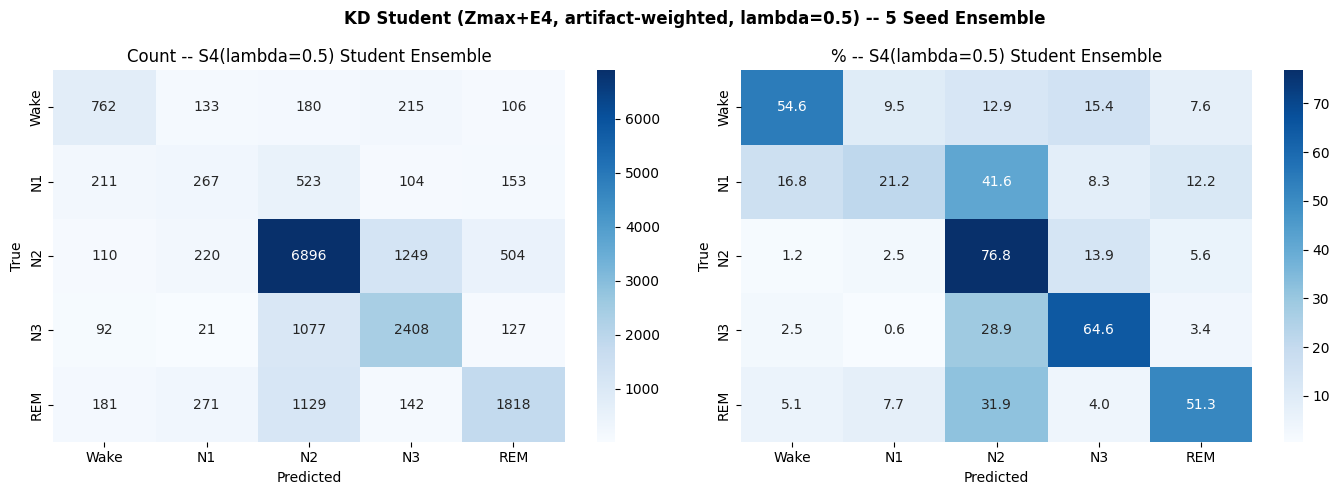


Outputs saved: D:\22\AA\evaluation\teacher-student\ensemble_s4_lambda0.5
Done!


In [1]:
# ============================================================
# ENSEMBLE EVALUATION -- S4 (KD_LAMBDA=0.5, artifact-weighted
# CE + KD, concat fusion) student, 5 seeds, soft vote.
#
# Loads the 5 best_student_seed*.pt checkpoints already saved
# by the S4(lambda=0.5) training run and combines predictions.
# ============================================================

import os
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================
# PATHS
# ============================================================
PSG_EEG_PATH      = r"D:\22\AA\preprocess\preprocessed_FFinal"
STUDENT_DATA_PATH = r"D:\22\AA\preprocess\preprocessed_student_zmax_e4"
CHECKPOINT_DIR    = r"D:\22\AA\evaluation\teacher-student\s3_artifact_weighted_kd=0.5"
EVAL_PATH         = r"D:\22\AA\evaluation\teacher-student\ensemble_s4_lambda0.5"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 7
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

S_D_MODEL = 96
S_DROPOUT = 0.3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device         : {device}")
print(f"Checkpoint dir : {CHECKPOINT_DIR}")
print(f"Output         : {EVAL_PATH}")


# ============================================================
# FIXED TEST SPLIT
# ============================================================
_test_path = os.path.join(PSG_EEG_PATH, "_test_subs.npy")
TEST_SUBS  = np.load(_test_path, allow_pickle=True).tolist()
print(f"Test subjects  : {len(TEST_SUBS)}")


# ============================================================
# DATASET (Zmax + E4 only -- student doesn't need PSG at inference)
# ============================================================
class WearableTestDataset(Dataset):
    def __init__(self, subject_list, data_path):
        self.data  = []
        self.index = []
        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                zmax_arr = d['zmax_eeg']
                e4_arr   = d['e4']
                labels   = d['labels'].copy()
            n = min(zmax_arr.shape[0], e4_arr.shape[0], len(labels))
            sub_idx = len(self.data)
            self.data.append((zmax_arr[:n], e4_arr[:n], labels[:n]))
            for i in range(n):
                self.index.append((sub_idx, i))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, i = self.index[idx]
        zmax_arr, e4_arr, labels = self.data[sub_idx]
        return (
            torch.FloatTensor(zmax_arr[i]),
            torch.FloatTensor(e4_arr[i]),
            torch.tensor(int(labels[i]), dtype=torch.long),
        )


print("\nLoading test dataset (Zmax+E4 only, no PSG needed)...")
test_ds     = WearableTestDataset(TEST_SUBS, STUDENT_DATA_PATH)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Test samples: {len(test_ds):,}")


# ============================================================
# STUDENT ARCHITECTURE (identical to S4 training script)
# ============================================================
class ZmaxEEGEncoder(nn.Module):
    def __init__(self, in_ch=2, d_model=S_D_MODEL, dropout=S_DROPOUT):
        super().__init__()
        mid = d_model // 2

        def branch(kernel):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=kernel, stride=4, padding=kernel // 2),
                nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(2, 2), nn.Dropout(dropout)
            )
        self.small, self.large = branch(15), branch(60)
        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, 1920)
            L_s, L_l = self.small(dummy).shape[2], self.large(dummy).shape[2]
        target_L = min(L_s, L_l)
        self.pool_s = nn.AdaptiveAvgPool1d(target_L)
        self.pool_l = nn.AdaptiveAvgPool1d(target_L)
        self.proj = nn.Sequential(nn.Conv1d(2 * mid, d_model, kernel_size=1),
                                   nn.BatchNorm1d(d_model), nn.GELU())
        self.gru = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        fs, fl = self.pool_s(self.small(x)), self.pool_l(self.large(x))
        feat = self.proj(torch.cat([fs, fl], dim=1)).permute(0, 2, 1)
        gru_out, _ = self.gru(feat)
        return self.norm(feat.mean(dim=1) + gru_out.mean(dim=1))


class E4Encoder(nn.Module):
    def __init__(self, in_ch=3, d_model=S_D_MODEL, dropout=S_DROPOUT):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, d_model // 2, kernel_size=15, stride=4, padding=7),
            nn.BatchNorm1d(d_model // 2), nn.GELU(), nn.MaxPool1d(2, 2),
            nn.Conv1d(d_model // 2, d_model, kernel_size=8, padding=4),
            nn.BatchNorm1d(d_model), nn.GELU(), nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )
        self.gru = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        feat = self.conv(x).permute(0, 2, 1)
        gru_out, _ = self.gru(feat)
        return self.norm(feat.mean(dim=1) + gru_out.mean(dim=1))


class WearableStudentModel(nn.Module):
    """Identical to S4 -- simple concat fusion, no gate."""
    def __init__(self, d_model=S_D_MODEL, n_classes=5, dropout=S_DROPOUT):
        super().__init__()
        self.zmax_enc = ZmaxEEGEncoder(in_ch=2, d_model=d_model, dropout=dropout)
        self.e4_enc   = E4Encoder(in_ch=3, d_model=d_model, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model * 2), nn.Linear(d_model * 2, 64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, n_classes)
        )

    def forward(self, zmax_x, e4_x):
        z = self.zmax_enc(zmax_x)
        e = self.e4_enc(e4_x)
        fused = torch.cat([z, e], dim=1)
        logits = self.classifier(fused)
        return logits


# ============================================================
# LOAD 5 STUDENT CHECKPOINTS
# ============================================================
print(f"\nLoading 5 student checkpoints from:\n  {CHECKPOINT_DIR}")
models = []
for seed in SEEDS:
    ckpt = os.path.join(CHECKPOINT_DIR, f"best_student_seed{seed}.pt")
    if not os.path.exists(ckpt):
        print(f"  X NOT FOUND: best_student_seed{seed}.pt")
        continue
    m = WearableStudentModel().to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()
    models.append((seed, m))
    print(f"  OK Loaded: best_student_seed{seed}.pt")

print(f"\nEnsemble size: {len(models)} models")


# ============================================================
# COLLECT LABELS
# ============================================================
all_labels = []
with torch.no_grad():
    for zmax_x, e4_x, y in test_loader:
        all_labels.extend(y.numpy())
all_labels = np.array(all_labels)


# ============================================================
# INFERENCE
# ============================================================
print("\nRunning ensemble inference...")
all_probs = []
for seed, model in models:
    model_probs = []
    with torch.no_grad():
        for zmax_x, e4_x, y in test_loader:
            logits = model(zmax_x.to(device), e4_x.to(device))
            probs = F.softmax(logits, dim=1).cpu().numpy()
            model_probs.append(probs)
    model_probs = np.concatenate(model_probs, axis=0)
    all_probs.append(model_probs)
    print(f"  seed={seed} done")

all_probs = np.stack(all_probs, axis=0)   # (5, N, 5)


# ============================================================
# SOFT VOTE
# ============================================================
ensemble_probs = all_probs.mean(axis=0)
ensemble_preds = ensemble_probs.argmax(axis=1)

acc     = accuracy_score(all_labels, ensemble_preds)
f1      = f1_score(all_labels, ensemble_preds, average='macro', zero_division=0)
kappa   = cohen_kappa_score(all_labels, ensemble_preds)
per_cls = f1_score(all_labels, ensemble_preds, average=None, zero_division=0)

print(f"\n{'='*55}")
print(f"S4(lambda=0.5) STUDENT ENSEMBLE RESULT (5 seeds, soft vote)")
print(f"{'='*55}")
print(f"  Accuracy    : {acc*100:.2f}%")
print(f"  Macro F1    : {f1:.4f}")
print(f"  Cohen Kappa : {kappa:.4f}")
print("  Per-class F1:")
for i, name in enumerate(LABEL_NAMES):
    bar = chr(9608) * int(per_cls[i] * 16)
    print(f"    {name:6s}: {per_cls[i]:.4f}  {bar}")
print(f"{'='*55}")


# ============================================================
# FINAL COMPARISON
# ============================================================
print(f"\n{'='*70}")
print("FINAL COMPARISON TABLE")
print(f"{'='*70}")
print(f"{'Model':<50} {'Acc%':>7} {'F1':>7}")
print("-" * 70)
print(f"{'S1: Wearable baseline (no KD)':<50} {'57.09':>7} {'0.5112':>7}")
print(f"{'S2: KD + concat, lambda=1.0':<50} {'61.86':>7} {'0.5219':>7}")
print(f"{'S4: KD + artifact-weighted, lambda=0.5 (single)':<50} {'62.18':>7} {'0.5277':>7}")
print(f"{'S4(lambda=0.5) ENSEMBLE (this)':<50} {acc*100:>7.2f} {f1:>7.4f}")
print(f"{'Teacher (PSG, reference)':<50} {'85.09':>7} {'0.8126':>7}")
print(f"{'='*70}")

print("\nInterpretation:")
print("  Compare this ensemble F1 against the single-model mean")
print("  (0.5277). Ensembling typically adds +0.3 to +0.6 F1 points.")
print("  This is your strongest wearable-only (PSG-free at inference)")
print("  result to date and should be the headline number reported")
print("  for the KD student in your thesis, unless the context-window")
print("  variant (separate script) outperforms it.")


# ============================================================
# CONFUSION MATRIX
# ============================================================
cm     = confusion_matrix(all_labels, ensemble_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,     annot=True, fmt='d',   xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[0])
axes[0].set_title("Count -- S4(lambda=0.5) Student Ensemble")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

sns.heatmap(cm_pct, annot=True, fmt='.1f', xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[1])
axes[1].set_title("% -- S4(lambda=0.5) Student Ensemble")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

fig.suptitle("KD Student (Zmax+E4, artifact-weighted, lambda=0.5) -- 5 Seed Ensemble",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_ensemble.png"), dpi=150)
plt.show()

print(f"\nOutputs saved: {EVAL_PATH}")
print("Done!")

In [1]:
# ============================================================
# S4: KD STUDENT + ARTIFACT-WEIGHTED LOSS (no gate)
#
# S3's artifact-GATED fusion underperformed S2's simple concat
# fusion (F1: 0.5185 < 0.5219). Instead of shifting trust toward
# E4 on noisy epochs (gating), this script keeps the simpler S2
# architecture (concat fusion) and instead scales each epoch's
# contribution to the LOSS by its Zmax artifact quality:
#
#   clean epoch  (artifact_weight = 1.0) -> full loss contribution
#   noisy epoch  (artifact_weight < 1.0) -> reduced loss contribution
#   no-data epoch(artifact_weight = 0.0) -> excluded from CE entirely
#
# i.e. the model still SEES both Zmax and E4 for every epoch
# (no gating/re-routing), but it is trained to rely less on what
# it learns from noisy epochs overall, and more on clean ones --
# exactly the "learn less from noisy, more from clean" behavior
# you asked for, applied at the loss level rather than the
# fusion level.
#
#   L = L_artifact-weighted-CE + lambda_KD * L_KD
#
# Compare against S2 (F1=0.5219, no artifact info at all) and
# S3 (F1=0.5185, gated fusion) to see which mechanism for using
# artifact information actually helps.
# ============================================================

import os
import csv
import math
import random
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
warnings.filterwarnings('ignore')

# ============================================================
# PATHS
# ============================================================
PSG_EEG_PATH      = r"D:\22\AA\preprocess\preprocessed_FFinal"
STUDENT_DATA_PATH = r"D:\22\AA\preprocess\preprocessed_student_zmax_e4"
TEACHER_CKPT_DIR  = r"D:\22\AA\evaluation\multiscale_plain_c7_88%"
EVAL_PATH         = r"D:\22\AA\evaluation\teacher-student\s3_artifact_weighted_kd=0.3"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 7
WINDOW      = 2 * CONTEXT + 1
N_EPOCHS    = 30
BATCH_SIZE  = 64
SEEDS         = [42, 123, 256, 789, 999]
TEACHER_SEEDS = [42, 123, 256, 789, 999]

T_D_MODEL = 128
T_DROPOUT = 0.4
T_N_HEADS = 4

S_D_MODEL = 96
S_DROPOUT = 0.3

KD_LAMBDA      = 0.3
KD_TEMPERATURE = 3.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"S4: Concat fusion (same as S2) + KD + ARTIFACT-WEIGHTED CE loss")
print(f"KD lambda     : {KD_LAMBDA}   Temperature: {KD_TEMPERATURE}")
print(f"Teacher       : MultiScaleSleepNetPlain, 5-seed ensemble (frozen)")
print(f"Output        : {EVAL_PATH}")


# ============================================================
# ============  TEACHER ARCHITECTURE (frozen)  ================
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.shape
        s = self.pool(x).view(b, c)
        s = self.fc(s).view(b, c, 1)
        return x * s


class MultiScaleCNN(nn.Module):
    def __init__(self, in_ch=3, d_model=T_D_MODEL, dropout=T_DROPOUT):
        super().__init__()
        mid = d_model // 4

        def time_branch(kernel):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=kernel, stride=6, padding=kernel // 2),
                nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(4, 4),
                nn.Conv1d(mid, mid, kernel_size=8, padding=4),
                nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(2, 2),
                nn.Dropout(dropout),
            )

        self.small  = time_branch(25)
        self.medium = time_branch(50)
        self.large  = time_branch(100)

        self.spectral = nn.Sequential(
            nn.Conv1d(in_ch, mid, kernel_size=25, stride=6, padding=12),
            nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(4, 4),
            nn.Conv1d(mid, mid, kernel_size=8, padding=4),
            nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, 3000)
            L_s = self.small(dummy).shape[2]
            L_m = self.medium(dummy).shape[2]
            L_l = self.large(dummy).shape[2]
            L_f = self.spectral(dummy).shape[2]

        target_L = min(L_s, L_m, L_l, L_f)
        self.pool_s = nn.AdaptiveAvgPool1d(target_L)
        self.pool_m = nn.AdaptiveAvgPool1d(target_L)
        self.pool_l = nn.AdaptiveAvgPool1d(target_L)
        self.pool_f = nn.AdaptiveAvgPool1d(target_L)
        self.out_len = target_L

        self.se = SEBlock(4 * mid)
        self.proj = nn.Sequential(
            nn.Conv1d(4 * mid, d_model, kernel_size=1),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )

    def forward(self, x):
        fs = self.pool_s(self.small(x))
        fm = self.pool_m(self.medium(x))
        fl = self.pool_l(self.large(x))

        x_fft = torch.fft.rfft(x, dim=-1)
        x_mag = torch.abs(x_fft)
        if x_mag.shape[-1] < x.shape[-1]:
            pad = x.shape[-1] - x_mag.shape[-1]
            x_mag = F.pad(x_mag, (0, pad))
        else:
            x_mag = x_mag[..., :x.shape[-1]]
        ff = self.pool_f(self.spectral(x_mag))

        feat = torch.cat([fs, fm, fl, ff], dim=1)
        feat = self.se(feat)
        return self.proj(feat)


class BiLSTMTransformerBlock(nn.Module):
    def __init__(self, d_model=T_D_MODEL, n_heads=T_N_HEADS, dropout=T_DROPOUT):
        super().__init__()
        self.bilstm = nn.LSTM(
            d_model, d_model // 2, num_layers=1,
            batch_first=True, bidirectional=True
        )
        self.norm1 = nn.LayerNorm(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 2, dropout=dropout,
            batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        lstm_out, _ = self.bilstm(x)
        x = self.norm1(x + lstm_out)
        attn_out = self.transformer(x)
        return self.norm2(x + attn_out)


class MultiScaleSleepNetPlain(nn.Module):
    """Teacher architecture -- identical to your trained checkpoints."""
    def __init__(self, in_ch=3, d_model=T_D_MODEL, n_layers=2,
                 dropout=T_DROPOUT, n_classes=5, context=CONTEXT):
        super().__init__()
        self.context = context
        self.d_model = d_model
        self.cnn = MultiScaleCNN(in_ch=in_ch, d_model=d_model, dropout=dropout)
        self.intra_blocks = nn.Sequential(*[
            BiLSTMTransformerBlock(d_model, dropout=dropout) for _ in range(n_layers)
        ])
        self.inter_pos = nn.Parameter(torch.randn(1, WINDOW, d_model) * 0.01)
        self.inter_blocks = nn.Sequential(*[
            BiLSTMTransformerBlock(d_model, dropout=dropout) for _ in range(n_layers)
        ])
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, n_classes),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        cnn_out = self.cnn(x.view(B * W, C, T)).permute(0, 2, 1)
        intra = self.intra_blocks(cnn_out)
        epoch_feat = intra.mean(dim=1).view(B, W, self.d_model)
        inter = self.inter_blocks(epoch_feat + self.inter_pos)
        center = inter[:, self.context, :]
        return self.classifier(center)


# ============================================================
# ========  STUDENT ARCHITECTURE (S2's concat fusion)  =========
# No gate -- both modalities always contribute equally to the
# representation. Artifact info is used ONLY in the loss below.
# ============================================================
class ZmaxEEGEncoder(nn.Module):
    def __init__(self, in_ch=2, d_model=S_D_MODEL, dropout=S_DROPOUT):
        super().__init__()
        mid = d_model // 2

        def branch(kernel):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=kernel, stride=4, padding=kernel // 2),
                nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(2, 2), nn.Dropout(dropout)
            )
        self.small, self.large = branch(15), branch(60)
        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, 1920)
            L_s, L_l = self.small(dummy).shape[2], self.large(dummy).shape[2]
        target_L = min(L_s, L_l)
        self.pool_s = nn.AdaptiveAvgPool1d(target_L)
        self.pool_l = nn.AdaptiveAvgPool1d(target_L)
        self.proj = nn.Sequential(nn.Conv1d(2 * mid, d_model, kernel_size=1),
                                   nn.BatchNorm1d(d_model), nn.GELU())
        self.gru = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        fs, fl = self.pool_s(self.small(x)), self.pool_l(self.large(x))
        feat = self.proj(torch.cat([fs, fl], dim=1)).permute(0, 2, 1)
        gru_out, _ = self.gru(feat)
        return self.norm(feat.mean(dim=1) + gru_out.mean(dim=1))


class E4Encoder(nn.Module):
    def __init__(self, in_ch=3, d_model=S_D_MODEL, dropout=S_DROPOUT):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, d_model // 2, kernel_size=15, stride=4, padding=7),
            nn.BatchNorm1d(d_model // 2), nn.GELU(), nn.MaxPool1d(2, 2),
            nn.Conv1d(d_model // 2, d_model, kernel_size=8, padding=4),
            nn.BatchNorm1d(d_model), nn.GELU(), nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )
        self.gru = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        feat = self.conv(x).permute(0, 2, 1)
        gru_out, _ = self.gru(feat)
        return self.norm(feat.mean(dim=1) + gru_out.mean(dim=1))


class WearableStudentModel(nn.Module):
    """Identical to S2 -- simple concat fusion, no gate."""
    def __init__(self, d_model=S_D_MODEL, n_classes=5, dropout=S_DROPOUT):
        super().__init__()
        self.zmax_enc = ZmaxEEGEncoder(in_ch=2, d_model=d_model, dropout=dropout)
        self.e4_enc   = E4Encoder(in_ch=3, d_model=d_model, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model * 2), nn.Linear(d_model * 2, 64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, n_classes)
        )

    def forward(self, zmax_x, e4_x):
        z = self.zmax_enc(zmax_x)
        e = self.e4_enc(e4_x)
        fused = torch.cat([z, e], dim=1)
        logits = self.classifier(fused)
        return logits


# ============================================================
# COMBINED DATASET (returns artifact_weight, used only in loss)
# ============================================================
class KDDataset(Dataset):
    def __init__(self, subject_list, psg_path, student_path, context=CONTEXT):
        self.context = context
        self.data = []
        self.index = []

        skipped_mismatch = 0
        for sub in subject_list:
            psg_fp = os.path.join(psg_path, f"{sub}.npz")
            stu_fp = os.path.join(student_path, f"{sub}.npz")
            if not (os.path.exists(psg_fp) and os.path.exists(stu_fp)):
                continue

            with np.load(psg_fp) as d:
                eeg = d['eeg'][:, [0, 1], :]
                eog = d['eog'][:, [0], :]
                psg_signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                psg_labels = d['labels'].copy()

            with np.load(stu_fp) as d:
                zmax_arr = d['zmax_eeg']
                e4_arr   = d['e4']
                stu_labels = d['labels'].copy()
                art_w = d['artifact_weight']

            n = min(len(psg_labels), len(stu_labels))
            if abs(len(psg_labels) - len(stu_labels)) > 5:
                skipped_mismatch += 1

            sub_idx = len(self.data)
            self.data.append((psg_signal, psg_labels, zmax_arr, e4_arr, art_w, stu_labels))
            for i in range(n):
                self.index.append((sub_idx, i, n))

        print(f"  Subjects loaded: {len(self.data)}  (large mismatches: {skipped_mismatch})")
        print(f"  Samples: {len(self.index):,}")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n = self.index[idx]
        psg_signal, psg_labels, zmax_arr, e4_arr, art_w, stu_labels = self.data[sub_idx]

        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(psg_signal[ei])
        psg_x = np.stack(window_epochs, axis=0)

        ei = min(center_i, zmax_arr.shape[0] - 1, e4_arr.shape[0] - 1)
        zmax_x = zmax_arr[ei]
        e4_x   = e4_arr[ei]
        aw     = float(art_w[ei]) if ei < len(art_w) else 1.0

        y = int(stu_labels[center_i]) if center_i < len(stu_labels) else int(psg_labels[center_i])

        return (
            torch.FloatTensor(psg_x),
            torch.FloatTensor(zmax_x),
            torch.FloatTensor(e4_x),
            torch.tensor(aw, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long),
        )


# ============================================================
# LOAD SPLIT + BUILD DATASETS
# ============================================================
_train_path = os.path.join(PSG_EEG_PATH, "_train_subs.npy")
_test_path  = os.path.join(PSG_EEG_PATH, "_test_subs.npy")
TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
print(f"Split loaded -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")

print("\nBuilding KD datasets...")
train_ds = KDDataset(TRAIN_SUBS, PSG_EEG_PATH, STUDENT_DATA_PATH)
print()
test_ds  = KDDataset(TEST_SUBS, PSG_EEG_PATH, STUDENT_DATA_PATH)
print("Datasets ready.")


# ============================================================
# LOAD FROZEN TEACHER ENSEMBLE
# ============================================================
print(f"\nLoading {len(TEACHER_SEEDS)} frozen teacher checkpoints...")
teachers = []
for seed in TEACHER_SEEDS:
    ckpt = os.path.join(TEACHER_CKPT_DIR, f"best_seed{seed}.pt")
    if not os.path.exists(ckpt):
        print(f"  MISSING: {ckpt}")
        continue
    m = MultiScaleSleepNetPlain(in_ch=3).to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()
    for p in m.parameters():
        p.requires_grad = False
    teachers.append(m)
print(f"Loaded {len(teachers)} teacher models (frozen).")


@torch.no_grad()
def teacher_soft_targets(psg_x, temperature=KD_TEMPERATURE):
    probs_sum = None
    for m in teachers:
        logits = m(psg_x)
        probs = F.softmax(logits / temperature, dim=1)
        probs_sum = probs if probs_sum is None else probs_sum + probs
    return probs_sum / len(teachers)


# ============================================================
# CLASS WEIGHTS
# ============================================================
all_train_labels = []
for _, _, _, _, _, labs in train_ds.data:
    all_train_labels.extend(labs.tolist())
label_counts = np.array([Counter(all_train_labels).get(i, 1) for i in range(5)], dtype=np.float32)
cw = torch.FloatTensor(label_counts.sum() / (5 * label_counts)).to(device)
print(f"\nClass weights: {dict(zip(LABEL_NAMES, cw.cpu().numpy().round(3)))}")


def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def artifact_weighted_kd_loss_fn(student_logits, teacher_probs, labels, artifact_weight,
                                  temperature, lam, class_weights):
    """
    L = artifact_weighted_CE + lambda_KD * L_KD

    The CE term is scaled per-sample by artifact_weight, so noisy
    epochs (low weight) contribute less to the gradient and clean
    epochs (weight=1.0) contribute fully. The KD term is left
    unweighted -- the teacher's soft label is still valid signal
    regardless of the STUDENT's input quality, since the teacher
    itself saw clean PSG for that epoch.
    """
    student_log_probs = F.log_softmax(student_logits / temperature, dim=1)
    kd = F.kl_div(student_log_probs, teacher_probs, reduction='batchmean') * (temperature ** 2)

    ce_per_sample = F.cross_entropy(student_logits, labels, weight=class_weights, reduction='none')
    weighted_ce = ce_per_sample * artifact_weight
    valid = artifact_weight > 0
    ce = weighted_ce[valid].mean() if valid.sum() > 0 else weighted_ce.mean()

    total = ce + lam * kd
    return total, kd.item(), ce.item()


def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = total_kd = total_ce = 0
    preds, labs_all = [], []
    for psg_x, zmax_x, e4_x, aw, y in loader:
        psg_x, zmax_x, e4_x, aw, y = (
            psg_x.to(device), zmax_x.to(device), e4_x.to(device),
            aw.to(device), y.to(device)
        )
        optimizer.zero_grad()
        teacher_probs = teacher_soft_targets(psg_x)
        student_logits = model(zmax_x, e4_x)
        loss, kd_val, ce_val = artifact_weighted_kd_loss_fn(
            student_logits, teacher_probs, y, aw, KD_TEMPERATURE, KD_LAMBDA, cw
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item(); total_kd += kd_val; total_ce += ce_val
        preds.extend(student_logits.argmax(1).cpu().numpy())
        labs_all.extend(y.cpu().numpy())

    n = len(loader)
    acc = accuracy_score(labs_all, preds)
    f1 = f1_score(labs_all, preds, average='macro', zero_division=0)
    return total_loss / n, total_kd / n, total_ce / n, acc, f1


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, labs_all, aw_all = [], [], []
    for psg_x, zmax_x, e4_x, aw, y in loader:
        zmax_x, e4_x = zmax_x.to(device), e4_x.to(device)
        logits = model(zmax_x, e4_x)
        preds.extend(logits.argmax(1).cpu().numpy())
        labs_all.extend(y.numpy())
        aw_all.extend(aw.numpy())
    preds, labs_all, aw_all = np.array(preds), np.array(labs_all), np.array(aw_all)

    acc = accuracy_score(labs_all, preds)
    f1 = f1_score(labs_all, preds, average='macro', zero_division=0)
    kappa = cohen_kappa_score(labs_all, preds)
    per_cls = f1_score(labs_all, preds, average=None, zero_division=0)

    clean_mask = aw_all >= 0.9
    noisy_mask = (aw_all > 0) & (aw_all < 0.5)
    clean_acc = accuracy_score(labs_all[clean_mask], preds[clean_mask]) if clean_mask.sum() > 0 else float('nan')
    noisy_acc = accuracy_score(labs_all[noisy_mask], preds[noisy_mask]) if noisy_mask.sum() > 0 else float('nan')

    return acc, f1, kappa, per_cls, clean_acc, noisy_acc


# ============================================================
# TRAINING LOOP
# ============================================================
csv_path = os.path.join(EVAL_PATH, "summary.csv")
fields = ["seed", "acc", "f1_macro", "kappa", "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM",
          "clean_acc", "noisy_acc"]
with open(csv_path, 'w', newline='') as f:
    csv.DictWriter(f, fields).writeheader()

all_results = []
for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}\nSTUDENT SEED {seed}  ({seed_idx+1}/{len(SEEDS)})\n{'='*60}")
    set_seed(seed)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=0, generator=torch.Generator().manual_seed(seed))
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = WearableStudentModel().to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Student parameters: {n_params:,}  (teacher frozen, not counted)")

    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=3e-4, betas=(0.9, 0.98), eps=1e-9)
    total_steps = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine)

    best_f1 = 0.0
    best_path = os.path.join(EVAL_PATH, f"best_student_seed{seed}.pt")

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_kd, tr_ce, tr_acc, tr_f1 = train_epoch(model, train_loader, optimizer, scheduler)
        vl_acc, vl_f1, vl_kap, vl_per, clean_acc, noisy_acc = evaluate(model, test_loader)

        saved = ""
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        print(f"  Ep[{epoch:02d}/{N_EPOCHS}] Loss:{tr_loss:.3f}(CE:{tr_ce:.3f}+KD:{tr_kd:.3f}) "
              f"TrF1:{tr_f1:.3f} ValAcc:{vl_acc:.3f} F1:{vl_f1:.3f} k:{vl_kap:.3f} "
              f"clean:{clean_acc:.3f} noisy:{noisy_acc:.3f}{saved}")

    model.load_state_dict(torch.load(best_path, map_location=device))
    fin_acc, fin_f1, fin_kap, fin_per, fin_clean, fin_noisy = evaluate(model, test_loader)

    print(f"\n  Seed {seed} FINAL: Acc={fin_acc*100:.2f}% F1={fin_f1:.4f} k={fin_kap:.4f}")
    print(f"  Clean-epoch acc: {fin_clean:.3f}   Noisy-epoch acc: {fin_noisy:.3f}")
    for i, name in enumerate(LABEL_NAMES):
        print(f"    {name:6s}: {fin_per[i]:.4f}")

    all_results.append({
        'seed': seed, 'acc': fin_acc, 'f1': fin_f1, 'kappa': fin_kap, 'per_cls': fin_per,
        'clean_acc': fin_clean, 'noisy_acc': fin_noisy
    })
    with open(csv_path, 'a', newline='') as f:
        csv.DictWriter(f, fields).writerow({
            "seed": seed, "acc": round(fin_acc, 4), "f1_macro": round(fin_f1, 4),
            "kappa": round(fin_kap, 4),
            "f1_Wake": round(fin_per[0], 4), "f1_N1": round(fin_per[1], 4),
            "f1_N2": round(fin_per[2], 4), "f1_N3": round(fin_per[3], 4),
            "f1_REM": round(fin_per[4], 4),
            "clean_acc": round(fin_clean, 4) if not np.isnan(fin_clean) else "",
            "noisy_acc": round(fin_noisy, 4) if not np.isnan(fin_noisy) else "",
        })

# ============================================================
# FINAL REPORT
# ============================================================
accs = np.array([r['acc'] for r in all_results]) * 100
f1s = np.array([r['f1'] for r in all_results])
kappas = np.array([r['kappa'] for r in all_results])

print(f"\n{'='*60}\nS4: KD + ARTIFACT-WEIGHTED CE (no gate) -- 5-SEED REPORT\n{'='*60}")
print(f"Accuracy : {accs.mean():.2f} +- {accs.std():.2f}%")
print(f"Macro F1 : {f1s.mean():.4f} +- {f1s.std():.4f}")
print(f"Kappa    : {kappas.mean():.4f} +- {kappas.std():.4f}")

print(f"\n{'='*60}\nFULL COMPARISON: S1 vs S2 vs S3 vs S4\n{'='*60}")
print(f"{'Model':<50} {'Acc%':>7} {'F1':>7}")
print("-" * 67)
print(f"{'S1: Wearable baseline (no KD)':<50} {'57.09':>7} {'0.5112':>7}")
print(f"{'S2: KD + concat fusion':<50} {'61.86':>7} {'0.5219':>7}")
print(f"{'S3: KD + artifact-GATED fusion':<50} {'60.59':>7} {'0.5185':>7}")
print(f"{'S4: KD + artifact-WEIGHTED loss (lamba=1)':<50}  {'62.18':>7} {'0.5207':>7}{'N1 F1(mean)0.217':>7}")
print(f"{'S4: KD + artifact-WEIGHTED loss (lamba=0.5)':<50} {'62.18':>7} {'0.5277':>7}{'N1 F1(mean)0.246':>7}")	

print(f"{'S4: KD + artifact-WEIGHTED loss (lamba=0.3)':<50} {accs.mean():>7.2f} {f1s.mean():>7.4f}")

print(f"{'Teacher (PSG, reference)':<50} {'85.09':>7} {'0.8126':>7}")
print("=" * 67)



print(f"\nSummary saved: {csv_path}")
print("Done!")

Device        : cuda
S4: Concat fusion (same as S2) + KD + ARTIFACT-WEIGHTED CE loss
KD lambda     : 0.3   Temperature: 3.0
Teacher       : MultiScaleSleepNetPlain, 5-seed ensemble (frozen)
Output        : D:\22\AA\evaluation\teacher-student\s3_artifact_weighted_kd=0.3
Split loaded -> Train:76  Test:20

Building KD datasets...
  Subjects loaded: 71  (large mismatches: 0)
  Samples: 66,763

  Subjects loaded: 19  (large mismatches: 0)
  Samples: 18,898
Datasets ready.

Loading 5 frozen teacher checkpoints...
Loaded 5 teacher models (frozen).

Class weights: {'Wake': np.float32(1.838), 'N1': np.float32(3.149), 'N2': np.float32(0.446), 'N3': np.float32(1.009), 'REM': np.float32(1.107)}

STUDENT SEED 42  (1/5)
  Student parameters: 153,989  (teacher frozen, not counted)
  Ep[01/30] Loss:3.041(CE:1.067+KD:6.580) TrF1:0.410 ValAcc:0.546 F1:0.434 k:0.319 clean:0.607 noisy:0.463 <- BEST
  Ep[02/30] Loss:2.518(CE:0.958+KD:5.202) TrF1:0.505 ValAcc:0.558 F1:0.450 k:0.338 clean:0.626 noisy:0.448 <